In [1]:
!pip install --upgrade keras==2.15.0
!pip install --upgrade tensorflow==2.15.0.post1
!pip install --upgrade scipy==1.11.4
!pip install tensorflow-addons==0.21.0

# clone Impala repository, refresh folder to see the Imapala repository
# runtime -> change runtime -> choose a gpu/tpu
!git clone https://github.com/hubtru/Impala

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 13.9 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.4.1
    Uninstalling keras-3.4.1:
      Successfully uninstalled keras-3.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.17.0 requires keras>=3.2.0, but you have keras 2.15.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.16.0
    Uninstalling wrapt-1.16.0:
      Succ

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_addons as tfa
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras as k
from keras import layers
from sklearn.model_selection import train_test_split
import cv2
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "2"

/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.11.0 and strictly below 2.14.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.15.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're u

In [3]:
# ============================== gpu info ==============================
print("Num GPUs Available: ", len(tf.config.list_physical_devices("GPU")))
print("GPUs: ", tf.config.list_physical_devices("GPU"))

Num GPUs Available:  0
GPUs:  []


In [4]:
# ============================== variables ==============================
# architecture
image_size = 256
filters = 256
depth = 4
columns = 4
widths = 4
kernel_size = 5
patch_size = 16
num_classes = 3

in_channel = 9
img_rows, img_cols = image_size, image_size
input_shape = (img_rows, img_cols, in_channel)

learning_rate = 0.001
weight_decay = 0.0001
batch_size = 8
epochs = 20

In [5]:
# ============================== paths ==============================
# needed for generate_data
modality = "scal"
exp_name = f"impala3d_v3_hexa_reg"
model_name = f"{exp_name}_{modality}"
model_save_path = f"{model_name}.h5"

# dataset
csv_path = "/content/Impala/dataset/labels_reg_sample.csv"
scal_path = f"/content/Impala/dataset/{modality}"

In [6]:
# ============================== load/prepare dataset ==============================
df = pd.read_csv(csv_path)

# RANDOM DATASET: we switch to toolbased
# shuffle, need same state for tool/scal/chips/multi
np.random.seed(55)
df = df.iloc[np.random.permutation(len(df))]
# train/test/val : 70/15/15
train_df, test_df = train_test_split(df, test_size=0.3)
test_df, val_df = train_test_split(test_df, test_size=0.5)

print(
    "size check train/test/val",
    len(train_df),
    len(test_df),
    len(val_df),
    (len(train_df) + len(test_df) + len(val_df)),
)

train_df["scal_x"] = train_df.id.map(lambda id: f"{scal_path}/x/{id}.png")
test_df["scal_x"] = test_df.id.map(lambda id: f"{scal_path}/x/{id}.png")
val_df["scal_x"] = val_df.id.map(lambda id: f"{scal_path}/x/{id}.png")

train_df["scal_y"] = train_df.id.map(lambda id: f"{scal_path}/y/{id}.png")
test_df["scal_y"] = test_df.id.map(lambda id: f"{scal_path}/y/{id}.png")
val_df["scal_y"] = val_df.id.map(lambda id: f"{scal_path}/y/{id}.png")

train_df["scal_z"] = train_df.id.map(lambda id: f"{scal_path}/z/{id}.png")
test_df["scal_z"] = test_df.id.map(lambda id: f"{scal_path}/z/{id}.png")
val_df["scal_z"] = val_df.id.map(lambda id: f"{scal_path}/z/{id}.png")


size check train/test/val 14 3 3 20


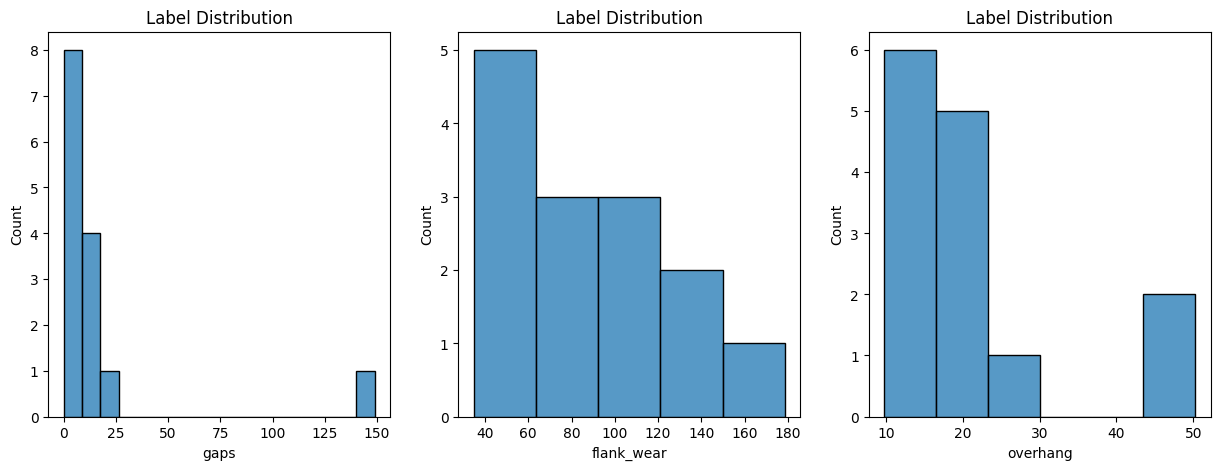

In [7]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
sns.histplot(train_df["gaps"], ax=ax[0])
sns.histplot(train_df["flank_wear"], ax=ax[1])
sns.histplot(train_df["overhang"], ax=ax[2])
ax[0].set_title("Label Distribution")
ax[1].set_title("Label Distribution")
ax[2].set_title("Label Distribution")
plt.show()

In [8]:
print("check if permutation is same on all models")
print("train_head", train_df.head())
print("test_head", test_df.head())
print("val_head", val_df.head())

check if permutation is same on all models
train_head          id   gaps  flank_wear  overhang  \
14   T8R3B4   6.88       40.92     14.54   
10   T6R9B3  12.94       95.63     16.65   
0    T1R2B1   7.67       34.89     48.61   
3   T2R13B4   0.00      122.59     25.55   
1    T1R7B4  13.89       85.41     50.25   

                                        scal_x  \
14   /content/Impala/dataset/scal/x/T8R3B4.png   
10   /content/Impala/dataset/scal/x/T6R9B3.png   
0    /content/Impala/dataset/scal/x/T1R2B1.png   
3   /content/Impala/dataset/scal/x/T2R13B4.png   
1    /content/Impala/dataset/scal/x/T1R7B4.png   

                                        scal_y  \
14   /content/Impala/dataset/scal/y/T8R3B4.png   
10   /content/Impala/dataset/scal/y/T6R9B3.png   
0    /content/Impala/dataset/scal/y/T1R2B1.png   
3   /content/Impala/dataset/scal/y/T2R13B4.png   
1    /content/Impala/dataset/scal/y/T1R7B4.png   

                                        scal_z  
14   /content/Impala/dataset/s

In [9]:
def read_specs(file_paths_x, file_paths_y, file_paths_z, img_rows, img_cols, channels):
    """
    Reads the spectogram files from disk and normalizes the pixel values
      @params:
        file_paths - Array of file paths to read from
        img_rows - The image height.
        img_cols - The image width.
        as_grey - Read the image as Greyscale or RGB.
        channels - Number of channels.
      @returns:
        The created and compiled model (Model)
    """
    images = []
    for i in range(file_paths_x.size):
        img = []
        img_x = cv2.imread(file_paths_x[i])
        res_x = cv2.resize(
            img_x, dsize=(img_rows, img_cols), interpolation=cv2.INTER_CUBIC
        )
        img.append(res_x)

        img_y = cv2.imread(file_paths_y[i])
        res_y = cv2.resize(
            img_y, dsize=(img_rows, img_cols), interpolation=cv2.INTER_CUBIC
        )
        img.append(res_y)

        img_z = cv2.imread(file_paths_z[i])
        res_z = cv2.resize(
            img_z, dsize=(img_rows, img_cols), interpolation=cv2.INTER_CUBIC
        )
        img.append(res_z)
        img = np.concatenate(img, axis=2)
        images.append(img)

    images = np.asarray(images, dtype=np.float32)

    # normalize
    images = images / np.max(images)

    return images

In [10]:
x_train_scal = read_specs(
    train_df.scal_x.values,
    train_df.scal_y.values,
    train_df.scal_z.values,
    img_rows,
    img_cols,
    in_channel,
)
x_test_scal = read_specs(
    test_df.scal_x.values,
    test_df.scal_y.values,
    test_df.scal_z.values,
    img_rows,
    img_cols,
    in_channel,
)
x_val_scal = read_specs(
    val_df.scal_x.values,
    val_df.scal_y.values,
    val_df.scal_z.values,
    img_rows,
    img_cols,
    in_channel,
)

In [11]:
x_train_scal.shape

(14, 256, 256, 9)

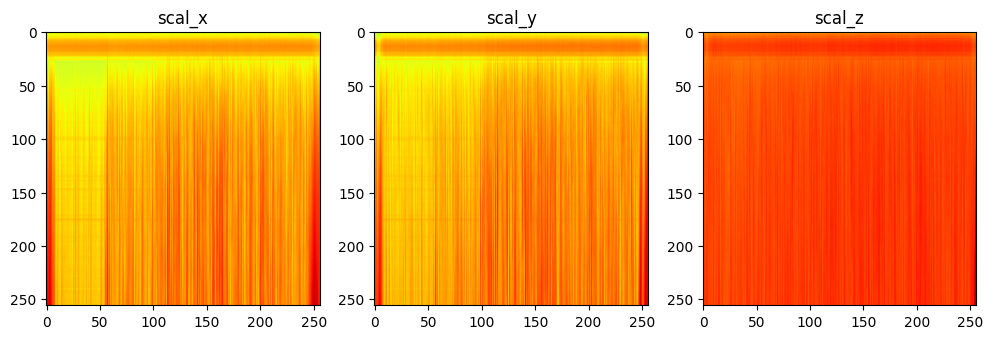

In [12]:
pil_img_x = tf.keras.utils.array_to_img(np.flip(x_train_scal[0][:,:,:3],axis=-1))
pil_img_y = tf.keras.utils.array_to_img(np.flip(x_train_scal[0][:,:,3:6],axis=-1))
pil_img_z = tf.keras.utils.array_to_img(np.flip(x_train_scal[0][:,:,6:9],axis=-1))

fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].imshow(pil_img_x)
ax[1].imshow(pil_img_y)
ax[2].imshow(pil_img_z)
ax[0].set_title("scal_x")
ax[1].set_title("scal_y")
ax[2].set_title("scal_z")
plt.show()

In [ ]:
labels_train = train_df[["gaps", "flank_wear", "overhang"]]
labels_test = test_df[["gaps", "flank_wear", "overhang"]]
labels_val = val_df[["gaps", "flank_wear", "overhang"]]

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_scal, labels_train))
test_dataset = tf.data.Dataset.from_tensor_slices((x_test_scal, labels_test))
val_dataset = tf.data.Dataset.from_tensor_slices((x_val_scal, labels_val))

In [ ]:
# ============================== augment ==============================
auto = tf.data.AUTOTUNE

data_augmentation = k.Sequential(
    [
        k.layers.RandomBrightness(factor=(-0.2, 0.2), value_range=(0, 1)),
        k.layers.RandomContrast(factor=0.2),
        k.layers.GaussianNoise(stddev=0.2),
    ],
    name="data_augmentation",
)

In [ ]:
def generate_datasets(images, is_train=False, shuffle=False):
    dataset = images
    if shuffle:
        dataset = dataset.shuffle(batch_size * 10)
    dataset = dataset.batch(batch_size)
    if is_train:
        dataset = dataset.map(
            lambda x, y: (data_augmentation(x), y), num_parallel_calls=auto
        )
    return dataset.prefetch(auto)

In [ ]:
train_ds = generate_datasets(train_dataset, is_train=True, shuffle=True)
val_ds = generate_datasets(val_dataset)
test_ds = generate_datasets(test_dataset)

In [ ]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 9), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float64, name=None))>

In [ ]:
# ============================== build model ==============================
def activation_block(x):
    x = layers.Activation("gelu")(x)
    return layers.BatchNormalization()(x)


def conv_stem(x, filters: int, patch_size: int):
    x = layers.Conv2D(filters, kernel_size=patch_size, strides=patch_size)(x)
    return activation_block(x)


def conv_mixer_block(
    x, pe_block, column, level, depth, width, r_arr, filters: int, kernel_size: int
):
    if column == 0:
        # Depthwise convolution.
        x0 = x
        x = layers.DepthwiseConv2D(kernel_size=kernel_size, padding="same")(x)
        x = layers.Add()([activation_block(x), x0])  # Residual.

        # Pointwise convolution.
        x = layers.Conv2D(filters, kernel_size=1)(x)
        x = activation_block(x)

        if width != 0:
            x0 = fusion_block_double(r_arr[width - 1][column][level], x0)

        r_arr = reverasable_output_array(x, r_arr, width, column, level)
        return x, r_arr
    elif column != 0:
        if level == 0:
            x0 = fusion_block_double(r_arr[width][column - 1][level + 1], pe_block)
        elif level <= depth - 2:
            x0 = fusion_block_double(r_arr[width][column - 1][level + 1], x)
            if width != 0:
                x = fusion_block_double(r_arr[width - 1][column - 1][level + 1], x)
        else:
            x0 = x
        x = layers.DepthwiseConv2D(kernel_size=kernel_size, padding="same")(x0)
        x = layers.Add()([activation_block(x), x0])  # Residual.

        # Pointwise convolution.
        x = layers.Conv2D(filters, kernel_size=1)(x)
        x = activation_block(x)

        x = fusion_block_double(r_arr[width][column - 1][level], x)
        if width != 0:
            x = fusion_block_double(r_arr[width - 1][column][level], x)

        r_arr = reverasable_output_array(x, r_arr, width, column, level)

        return x, r_arr

    return x, r_arr


def fusion_block_double(x, y):
    return layers.Add()([x, y])


def reverasable_output_array(x, r_arr, width, column, level):
    r_arr[width][column][level] = x
    return r_arr


def get_conv_mixer_256_8(
    image_size=image_size,
    filters=filters,
    depth=depth,
    columns=columns,
    width=widths,
    kernel_size=kernel_size,
    patch_size=patch_size,
    num_classes=num_classes,
):
    r_arr = [
        [[None for _ in range(depth)] for _ in range(columns)] for _ in range(width)
    ]

    inputs = k.Input(input_shape)
    # x = layers.Rescaling(scale=1.0 / 255)(inputs)         # already rescaled

    # Extract patch embeddings.
    x = conv_stem(inputs, filters, patch_size)
    pe_block = x

    # ConvMixer blocks.
    for w in range(width):
        for column in range(columns):
            for level in range(depth):
                x, r_arr = conv_mixer_block(
                    x, pe_block, column, level, depth, w, r_arr, filters, kernel_size
                )

    # Classification block.
    x = layers.GlobalAvgPool2D()(x)
    outputs = layers.Dense(num_classes, activation="linear")(x)

    return k.Model(inputs, outputs)

In [ ]:
# ============================== run experiment ==============================
def run_experiment(model):
    optimizer = tfa.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )

    model.compile(
        optimizer=optimizer, loss="mse", metrics=[tf.keras.metrics.MeanSquaredError()]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=2,
    )

    _, accuracy = model.evaluate(test_ds)
    print(f"Test error: {round(accuracy, 2)}")

    return history, model

In [ ]:
model = get_conv_mixer_256_8()
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 256, 256, 9)]        0         []                            
                                                                                                  
 conv2d_130 (Conv2D)         (None, 16, 16, 256)          590080    ['input_3[0][0]']             
                                                                                                  
 activation_258 (Activation  (None, 16, 16, 256)          0         ['conv2d_130[0][0]']          
 )                                                                                                
                                                                                                  
 batch_normalization_258 (B  (None, 16, 16, 256)          1024      ['activation_258[0][0]']

In [ ]:
history, model = run_experiment(model)

Epoch 1/20
2/2 - 110s - loss: 4095.8542 - mean_squared_error: 4095.8542 - val_loss: 148839.2500 - val_mean_squared_error: 148839.2500 - 110s/epoch - 55s/step
Epoch 2/20
2/2 - 5s - loss: 4123.1455 - mean_squared_error: 4123.1455 - val_loss: 721373.3125 - val_mean_squared_error: 721373.3125 - 5s/epoch - 3s/step
Epoch 3/20
2/2 - 8s - loss: 3562.0745 - mean_squared_error: 3562.0745 - val_loss: 548480.5000 - val_mean_squared_error: 548480.5000 - 8s/epoch - 4s/step
Epoch 4/20
2/2 - 6s - loss: 3306.4788 - mean_squared_error: 3306.4788 - val_loss: 549296.8125 - val_mean_squared_error: 549296.8125 - 6s/epoch - 3s/step
Epoch 5/20
2/2 - 10s - loss: 2943.6216 - mean_squared_error: 2943.6216 - val_loss: 243881.1875 - val_mean_squared_error: 243881.1875 - 10s/epoch - 5s/step
Epoch 6/20
2/2 - 6s - loss: 3001.0718 - mean_squared_error: 3001.0718 - val_loss: 268755.2188 - val_mean_squared_error: 268755.2188 - 6s/epoch - 3s/step
Epoch 7/20
2/2 - 6s - loss: 2589.0273 - mean_squared_error: 2589.0273 - val

In [ ]:
model.save(model_save_path)

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
pred = model.predict(test_ds)

1/1 [==============================] - 6s 6s/step


In [ ]:
# ============================== generate data ==============================
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import interp
from itertools import cycle
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.metrics import PredictionErrorDisplay
from sklearn import metrics
import tensorflow as tf
from tensorflow import keras as k

In [ ]:
multi_pred = pred
gaps_pred, flank_wear_pred, overhang_pred = multi_pred.T

multi_true = labels_test.to_numpy()
gaps_true, flank_wear_true, overhang_true = multi_true.T

In [ ]:
labels_list = [
    "gaps",
    "flank_wear",
    "overhang",
    "multi",
]
pred_list = [
    gaps_pred,
    flank_wear_pred,
    overhang_pred,
    multi_pred,
]
true_list = [
    gaps_true,
    flank_wear_true,
    overhang_true,
    multi_true,
]

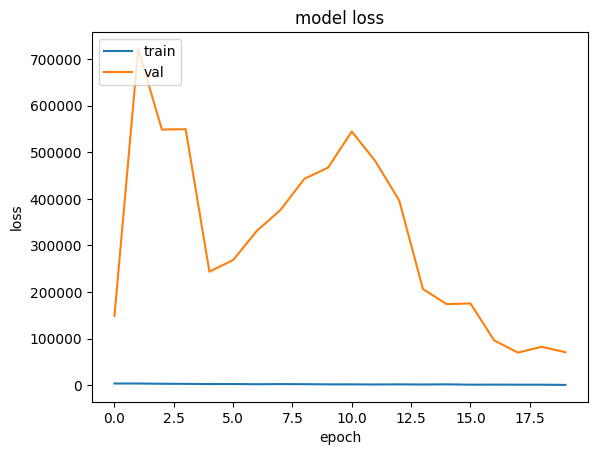

In [ ]:
# loss
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.show()

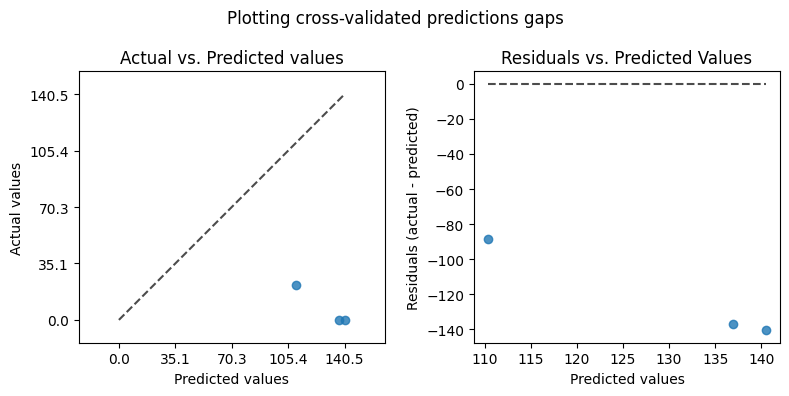

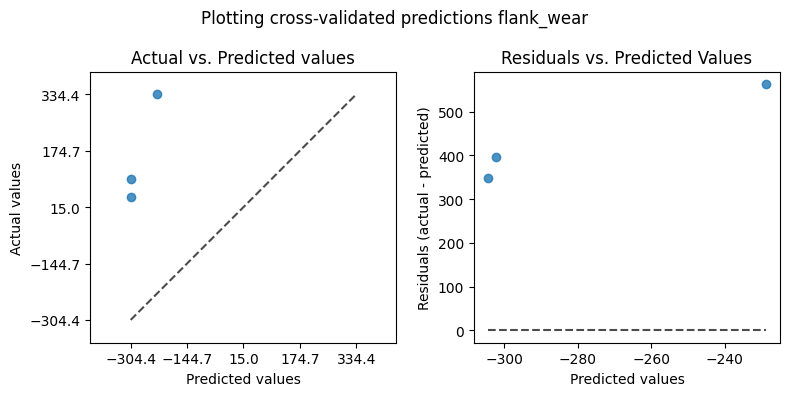

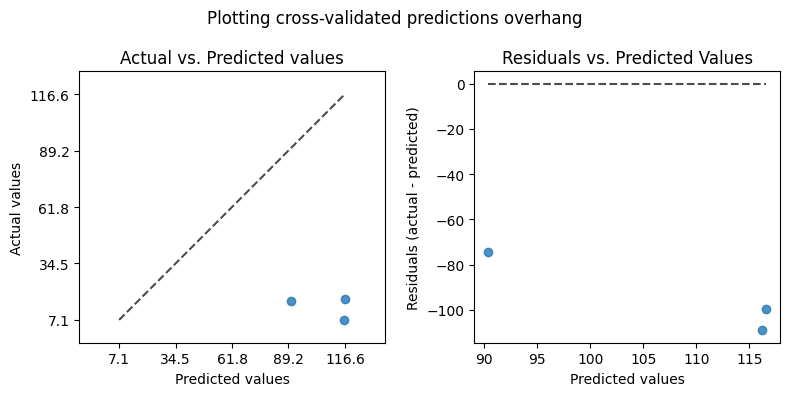

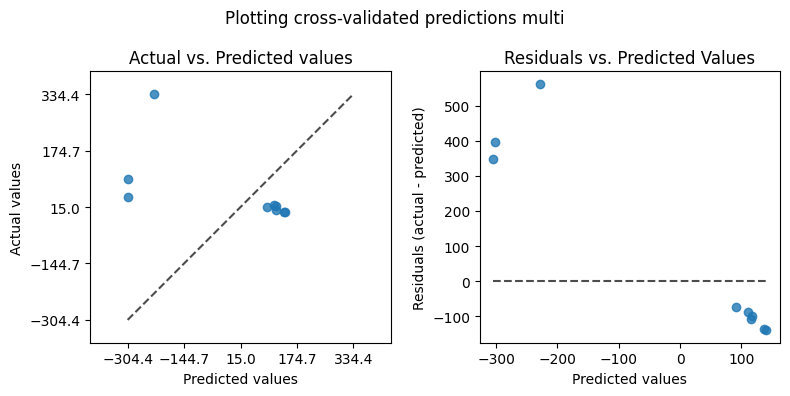

In [ ]:
for label, y_pred, y_true in zip(labels_list, pred_list, true_list):
    # https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_predict.html#sphx-glr-auto-examples-model-selection-plot-cv-predict-py
    fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
    PredictionErrorDisplay.from_predictions(
        y_true=y_true,
        y_pred=y_pred,
        kind="actual_vs_predicted",
        subsample=100,
        ax=axs[0],
        random_state=0,
    )
    axs[0].set_title("Actual vs. Predicted values")
    PredictionErrorDisplay.from_predictions(
        y_true=y_true,
        y_pred=y_pred,
        kind="residual_vs_predicted",
        subsample=100,
        ax=axs[1],
        random_state=0,
    )
    axs[1].set_title("Residuals vs. Predicted Values")
    fig.suptitle("Plotting cross-validated predictions " + label)
    plt.tight_layout()
    plt.show()

In [ ]:
def min_shift(list1, list2):
    list1 = np.array(list1)
    list2 = np.array(list2)
    if list1.ndim == 2:
        for i in range(len(list1)):
            if np.min([list1, list2]) > 0:
                continue
            min = np.min([list1[i], list2[i]])
            list1[i] -= min
            list2[i] -= min
        return list1, list2

    min = np.min([list1, list2])
    list1 = list1 - min
    list2 = list1 - min

    return list1, list2

In [ ]:
for label, y_pred, y_true in zip(labels_list, pred_list, true_list):
    print(f"===== {label} results =====")
    print("MAE: ", metrics.mean_absolute_error(y_true, y_pred))
    print("MSE: ", metrics.mean_squared_error(y_true, y_pred))
    print("RMSE: ", metrics.mean_squared_error(y_true, y_pred, squared=False))
    print("r2_score: ", metrics.r2_score(y_true, y_pred))
    try:
        print("MSLE: ", metrics.mean_squared_log_error(y_true, y_pred))
    except ValueError as err:
        y_true_shift, y_pred_shift = min_shift(y_true, y_pred)
        print(
            "MSLE_min_shifted: ",
            metrics.mean_squared_log_error(y_true_shift, y_pred_shift),
        )
    print("MAPE: ", metrics.mean_absolute_percentage_error(y_true, y_pred))

===== gaps results =====
MAE:  122.01841766357423
MSE:  15450.299479602043
RMSE:  124.29923362435524
r2_score:  -145.43164972292612
MSLE:  17.10640762688082
MAPE:  4.165745817556091e+17
===== flank_wear results =====
MAE:  436.2371608479818
MSE:  198742.35624035005
RMSE:  445.80528960561924
r2_score:  -11.404066079932694
MSLE_min_shifted:  0.2879464027501957
MAPE:  4.585491003995415
===== overhang results =====
MAE:  94.29299957275391
MSE:  9107.420816209697
RMSE:  95.43280786086981
r2_score:  -450.4777972720091
MSLE:  4.484315492982151
MAPE:  8.601726013910678
===== multi results =====
MAE:  217.51619269476998
MSE:  74433.35884538727
RMSE:  221.84577703028143
r2_score:  -202.43783769162266
MSLE_min_shifted:  12.320078455951972
MAPE:  1.3885819391853637e+17
